In [ ]:
import torch
from torch import nn, optim
import torch.nn as nn
import math
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_size, head_count):
        super(TransformerBlock, self).__init__()
        self.attention = nn.MultiheadAttention(embed_size, head_count, batch_first=True)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)
        self.feed_forward = nn.Sequential(
            nn.Linear(embed_size, 4*embed_size),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(4*embed_size, embed_size)
        )
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x_norm = self.norm1(x)
        attention_output, _ = self.attention(x_norm,x_norm,x_norm)
        x = x + self.dropout(attention_output)
        x_norm = self.norm2(x)
        ff_output = self.feed_forward(x_norm)
        x = x + self.dropout(ff_output)
        return x

class Transformer_learnable(nn.Module):
    def __init__(self, vocab_size, posi_size, embed_size, num_layers, head_count, LB):
        super(Transformer_learnable, self).__init__()
        self.embed_size = embed_size
        self.LB = LB

        # embed each z_bit ∈ {0,1}
        self.z_bit_embed = nn.Embedding(2, embed_size)
        # project flattened z_emb → one context token
        self.z_ffn = nn.Sequential(
            nn.Linear(LB * embed_size, embed_size),
            nn.ReLU()
        )

        # embedding for P/b tokens
        self.word_embedding = nn.Embedding(vocab_size, embed_size)
        self.position_embedding = nn.Embedding(posi_size, embed_size)

        # Transformer layers
        self.layers = nn.ModuleList(
            [TransformerBlock(embed_size, head_count) for _ in range(num_layers)]
        )

        # predict next b ∈ {0,1}
        self.fc_out = nn.Linear(embed_size, 2)
        self.tokendrop = nn.Dropout(0.25)

    def forward(self, inputs, mask=None):
        """
        inputs: LongTensor of shape (B, LB + T)
        """
        device = inputs.device
        B, total_len = inputs.size()

        # 1) embed z_bits
        z_bits = inputs[:, :self.LB].long()               # (B, LB)
        z_emb  = self.z_bit_embed(z_bits.to(device))      # (B, LB, D)
        z_flat = z_emb.flatten(start_dim=1)                # (B, LB*D)
        para_context = self.z_ffn(z_flat).unsqueeze(1)    # (B, 1, D)

        # 2) embed interleaved tokens
        token_inputs = inputs[:, self.LB:].long()         # (B, T)
        token_emb    = self.word_embedding(token_inputs.to(device))  # (B, T, D)
        positions    = torch.arange(token_inputs.size(1), device=device) \
                               .unsqueeze(0).expand(B, -1)         # (B, T)
        pos_emb      = self.position_embedding(positions)          # (B, T, D)
        token_emb    = token_emb + pos_emb                       # (B, T, D)
        token_emb    = self.tokendrop(token_emb)                  # 如果要用 dropout

        # 3) concat
        out = torch.cat((para_context, token_emb), dim=1)         # (B, 1+T, D)

        # 4) transformer layers
        for layer in self.layers:
            out = layer(out)

        # 5) predict next b
        logits = self.fc_out(out[:, -1, :])                       # (B, 2)
        return logits


def generate_with_z(z_bits, model, LA, sample_size, device):
    """
    Args:
        z_bits: 1D LongTensor of shape (LB,)  e.g. torch.tensor([0,1,0,1,1,0,0,1])
        model: your Transformer_learnable instance
        LA: number of subsystem A qubits (e.g. 2)
        sample_size: how many sequences to generate
        device: torch.device
    Returns:
        outputs: LongTensor of shape (sample_size, LB + 2*LA)
                 each row = [z1..z8, P1, b1, P2, b2]
    """
    LB = z_bits.numel()
    T = 2 * LA
    # 1) 初始化 outputs tensor
    outputs = torch.zeros((sample_size, LB + T), dtype=torch.long, device=device)
    # 2) 填入相同的 z_bits
    z_expand = z_bits.to(device).unsqueeze(0).expand(sample_size, LB)
    outputs[:, :LB] = z_expand

    # 3) 逐位生成 (P_i, b_i)
    for i in range(LA):
        P_col = LB + 2 * i
        b_col = P_col + 1

        # 隨機選一個 P ∈ {2,3,4}
        outputs[:, P_col] = torch.randint(2, 5, (sample_size,), device=device)

        # 呼叫 model，傳入到目前為止的 prefix
        logits = model(outputs[:, :P_col+1], device)  # shape (sample_size, 2)
        probs = F.softmax(logits, dim=1)

        # 從 Bernoulli(pred_b=1 機率) 取樣
        b_sample = torch.bernoulli(probs[:, 1]).to(torch.long)
        outputs[:, b_col] = b_sample

    return outputs

In [ ]:
# 1) 设定参数
LB = 14     # z₁…z₈
LA = 2     # 要生成 P1,b1,P2,b2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2) 定义你的 z 向量（1×8）
#    例如：z = [1,1,0,1,0,0,1,0,0,1,0,0,1,1]
z_bits = torch.tensor([1,1,0,1,0,0,1,0,0,1,0,0,1,1], dtype=torch.long)


# 3) 初始化并载入最优模型
model = Transformer_learnable(
    vocab_size=5,
    posi_size=4,      # 2*LA
    embed_size=128,
    num_layers=4,
    head_count=4,
    LB=LB
).to(device)
ckpt = torch.load("/content/drive/MyDrive/ShadowGPT_indefinite_charge_L=16/QB=7/best_model.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# 4) 调用我们之前定义的生成函数，生成 30 条样本
sample_size = 180000
with torch.no_grad():
    samples = generate_with_z(z_bits, model, LA, sample_size, device)

# 5) samples 的形状 = (30, LB + 2*LA) = (30, 12)
#    每一行 = [z1..z8, P1, b1, P2, b2]
#torch.set_printoptions(profile="full")
#print(samples)
#torch.set_printoptions(profile="default")

In [ ]:
# 定義 Pauli 基底（2=X,3=Y,4=Z）的本徵向量矩陣
pauli_bases = {
    2: np.array([[1,  1],
                  [1, -1]]) / np.sqrt(2),            # X basis
    3: np.array([[1, -1j],
                  [1j, -1]]) / np.sqrt(2),           # Y basis
    4: np.eye(2),                                 # Z basis
}

# 9 combinations of random Pauli
basis_list = [(p1, p2) for p1 in pauli_bases for p2 in pauli_bases]

In [ ]:
# 假设 samples 是 shape=(N, LB+2*LA) 的 LongTensor
arr = samples.cpu().numpy()
N, _ = arr.shape

# 先构造 (p1,p2)→index 的映射，和初始化计数矩阵 counts
mapping = {b: i for i, b in enumerate(basis_list)}   # basis_list 需和理论计算时保持一致
counts = np.zeros((len(basis_list), 2**LA), dtype=int)

# 遍历每一条生成样本
for row in arr:
    # row = [z1..z8, P1, b1, P2, b2]
    p1, b1, p2, b2 = int(row[LB]), int(row[LB+1]), int(row[LB+2]), int(row[LB+3])
    idx = mapping[(p1, p2)]
    outcome = b1*2 + b2     # 00→0, 01→1, 10→2, 11→3
    counts[idx, outcome] += 1

# 转成经验概率
empirical = counts / counts.sum(axis=1, keepdims=True)   # shape (9, 4)

# Functions for probabilities

In [ ]:
def construct_probs_array(psi, L, LA):
    """
    Measure the bath and obtain the bitstring z.
    Calculate the probability of each outcome under every possible combination of random Paulis.

    Return：
      P_z       : shape (2**(L-LA),)      — Probability to get z
      basis_list: list of (p1,p2) length 9 — p1,p2 ∈ {2,3,4} correspond to X,Y,Z.
      probs     : shape (2**(L-LA), 9, 2**LA)
    """
    LB = L - LA
    dim_A = 2**LA
    dim_B = 2**LB


    psi_mat = psi.reshape((dim_A, dim_B))
    # P(z) = ||ψ_A(z)||^2
    P_z = np.linalg.norm(psi_mat, axis=0)**2

    # 定義 Pauli 基底（2=X,3=Y,4=Z）的本徵向量矩陣
    pauli_bases = {
        2: np.array([[1,  1],
                     [1, -1]]) / np.sqrt(2),            # X basis
        3: np.array([[1, -1j],
                     [1j, -1]]) / np.sqrt(2),           # Y basis
        4: np.eye(2),                                 # Z basis
    }

    # 9 combinations of random Pauli
    basis_list = [(p1, p2) for p1 in pauli_bases for p2 in pauli_bases]

    probs = np.zeros((dim_B, len(basis_list), dim_A))

    for z in range(dim_B):
        psi_A_z = psi_mat[:, z]
        if P_z[z] == 0:
            continue
        # normalization
        psi_A_norm = psi_A_z / np.sqrt(P_z[z])
        for idx, (p1, p2) in enumerate(basis_list):
            U = np.kron(pauli_bases[p1], pauli_bases[p2])   # 4×4 transformation matrix
            amps = U.conj().T @ psi_A_norm
            probs[z, idx, :] = np.abs(amps)**2             # probabilities of 4 outcomes

    return P_z, basis_list, probs

# Calculate probabilities

In [ ]:
L = 16              # Total number of qubits in the system
LA = 2              # Subsystem A (e.g., first 2 qubits)
LB = L - LA         # Bath B (remaining qubits)
dim = 2**L         # Hilbert space dimension

thermalized_state = np.load('/content/drive/MyDrive/ShadowGPT_indefinite_charge_L=16/QB=7/thermalized_state.npy')
P_z, basis_list, probs = construct_probs_array(thermalized_state, L, LA)

#zbits = [0,0,0,1,1,1,1,0] #unseen
zbits = [1,1,0,1,0,0,1,0,0,1,0,0,1,1] #seen
decimal = int("".join(map(str, zbits)), 2)
probs[decimal]

array([[0.01912423, 0.3368185 , 0.44869855, 0.19535872],
       [0.15407591, 0.20186681, 0.57567417, 0.0683831 ],
       [0.25458991, 0.10135282, 0.47474116, 0.16931611],
       [0.1430063 , 0.25425913, 0.32481648, 0.27791809],
       [0.37725619, 0.02000924, 0.35249389, 0.25024068],
       [0.1318921 , 0.26537333, 0.59743897, 0.00529559],
       [0.25172369, 0.52233165, 0.21609909, 0.00984557],
       [0.66243887, 0.11161646, 0.06731122, 0.15863345],
       [0.62289186, 0.15116347, 0.10643921, 0.11950545]])

In [ ]:
empirical

array([[0.09088655, 0.2551071 , 0.39800674, 0.2559996 ],
       [0.21718424, 0.12957635, 0.59961306, 0.05362635],
       [0.24269493, 0.09957103, 0.29210194, 0.3656321 ],
       [0.11545969, 0.16530704, 0.31434863, 0.40488464],
       [0.24893883, 0.02786517, 0.39046192, 0.33273408],
       [0.07842047, 0.19698655, 0.66745879, 0.05713419],
       [0.24903761, 0.57481986, 0.14194058, 0.03420195],
       [0.75392644, 0.06954689, 0.08460033, 0.09192634],
       [0.63121102, 0.19141018, 0.04631865, 0.13106015]])

In [ ]:
theoretical = probs[decimal]

In [ ]:
from scipy.stats import entropy

eps = 1e-8  # 为了数值稳定

# 逐基底计算指标
tvd = 0.5 * np.abs(empirical - theoretical).sum(axis=1)       # Total Variation Distance
mse = ((empirical - theoretical)**2).mean(axis=1)             # 均方误差
kl  = np.array([
    entropy(empirical[i] + eps, theoretical[i] + eps)
    for i in range(len(basis_list))
])

# 打印各基底指标
for i, (p1,p2) in enumerate(basis_list):
    print(f"基底 ({p1},{p2}) → TVD={tvd[i]:.3f}, MSE={mse[i]:.3e}, KL={kl[i]:.3f}")

基底 (2,2) → TVD=0.132, MSE=4.518e-03, KL=0.092
基底 (2,3) → TVD=0.087, MSE=2.500e-03, KL=0.029
基底 (2,4) → TVD=0.196, MSE=1.801e-02, KL=0.126
基底 (3,2) → TVD=0.127, MSE=6.225e-03, KL=0.046
基底 (3,3) → TVD=0.128, MSE=6.193e-03, KL=0.040
基底 (3,4) → TVD=0.122, MSE=3.781e-03, KL=0.110
基底 (4,2) → TVD=0.077, MSE=2.214e-03, KL=0.035
基底 (4,3) → TVD=0.109, MSE=3.722e-03, KL=0.034
基底 (4,4) → TVD=0.060, MSE=1.359e-03, KL=0.027


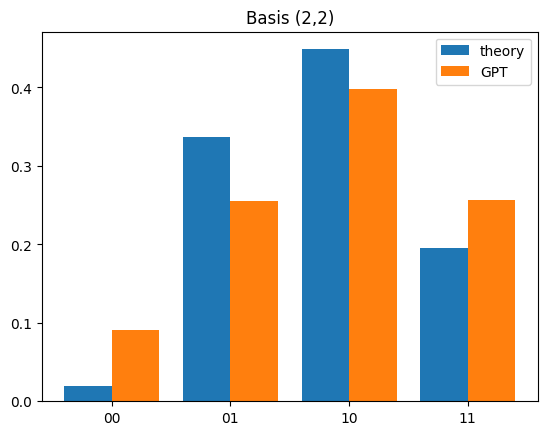

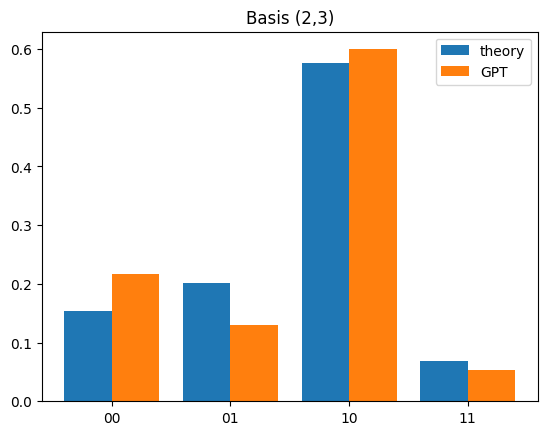

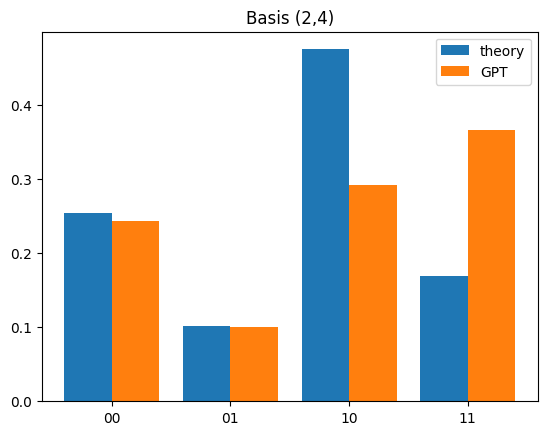

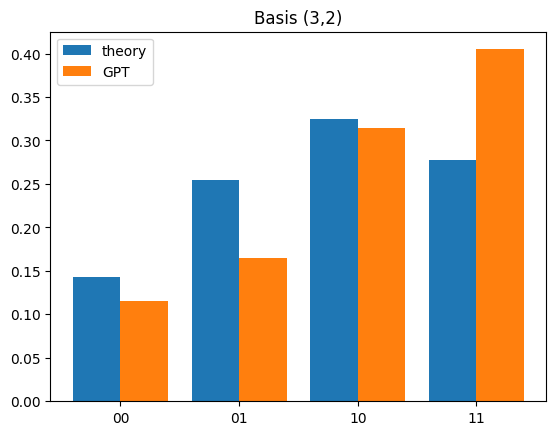

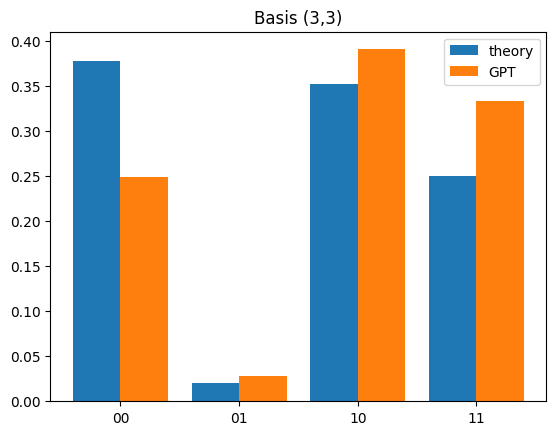

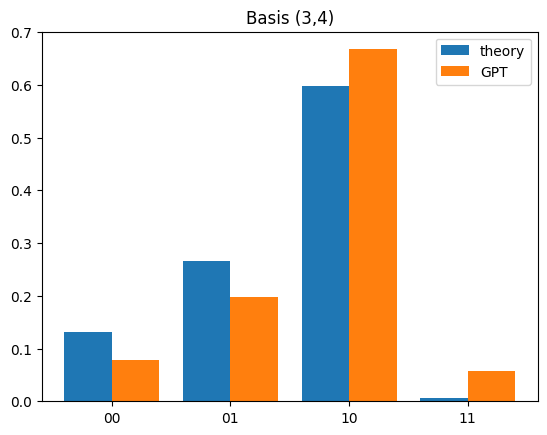

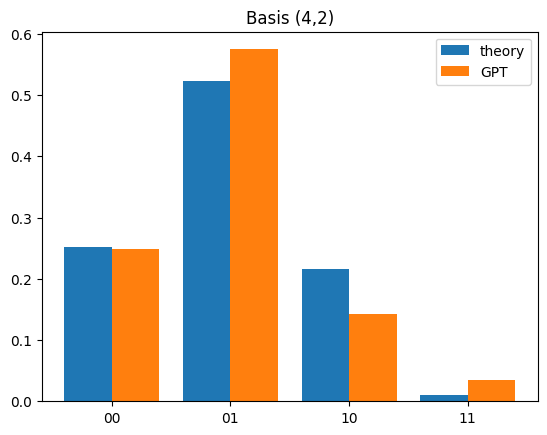

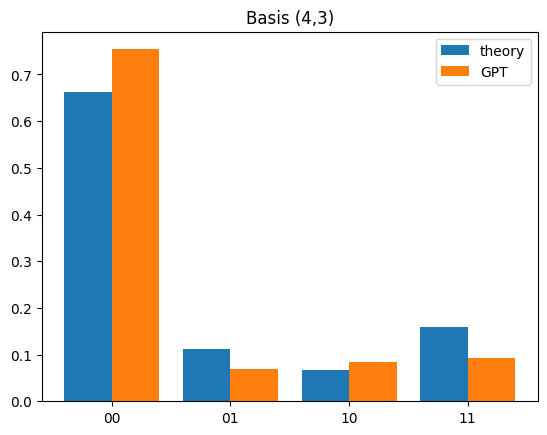

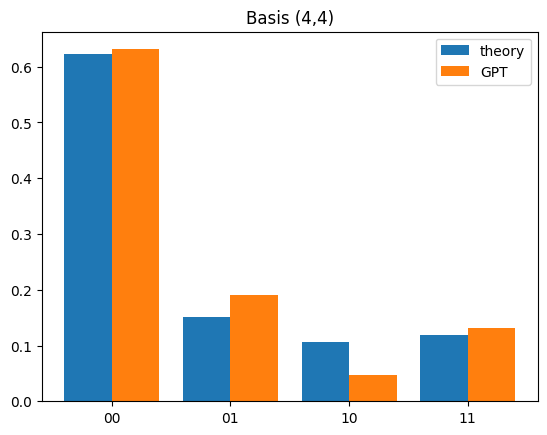

In [ ]:
import matplotlib.pyplot as plt

for i,(p1,p2) in enumerate(basis_list):
    plt.figure()
    x = np.arange(4)
    plt.bar(x-0.2, theoretical[i], width=0.4, label="theory")
    plt.bar(x+0.2, empirical[i]   , width=0.4, label="GPT")
    plt.xticks(x, ["00","01","10","11"])
    plt.title(f"Basis ({p1},{p2})")
    plt.legend()
    plt.show()